# Contextual Bandit Strategy Evaluation

This notebook evaluates contextual bandit strategies using **regularized logistic regression** to model action rewards. The goal is to compare different approaches and analyze their performance in balancing exploration and exploitation.

## Objectives:
- Implement and compare bandit strategies: Thompson Sampling, LinUCB, Epsilon-Greedy, Exploit-Only, and Random Selection.
- Measure performance using **cumulative regret** and **total reward**.
- Analyze the impact of exploration-exploitation parameters and batch updates.

We define various bandit strategies to evaluate their performance. The strategies are:

- **Thompson Sampling:** Balances exploration and exploitation based on Bayesian posterior sampling.
- **LinUCB:** Uses an upper confidence bound approach to select actions with high potential reward.
- **Exploit-Only:** Always selects the action with the highest estimated reward, leading to minimal exploration.
- **Epsilon-Greedy:** Randomly explores with a small probability (epsilon) while exploiting the best-known action otherwise.
- **Random:** Selects actions uniformly at random with no learning.

In [1]:
from main import evaluate_bandit
from utils import plot_results,plot_alpha_regret
import numpy as np

## Strategy Evaluation and Visualization

We evaluate multiple contextual bandit strategies by running simulations and tracking their performance. The results will be visualized in terms of cumulative regret and total rewards to compare the effectiveness of each approach.

Strategy: thompson, Total reward: 701/1000
Strategy: linucb, Total reward: 649/1000
Strategy: exploit, Total reward: 667/1000
Strategy: epsilon-greedy, Total reward: 632/1000
Strategy: random, Total reward: 192/1000


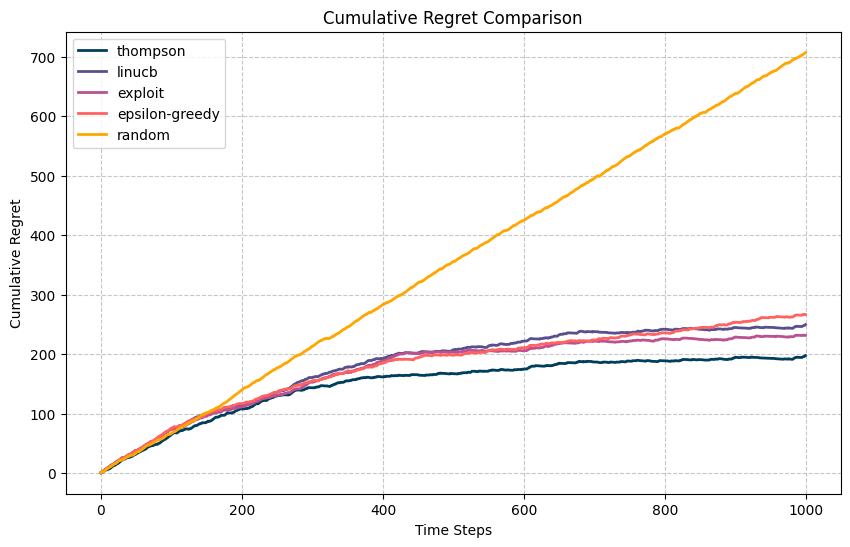

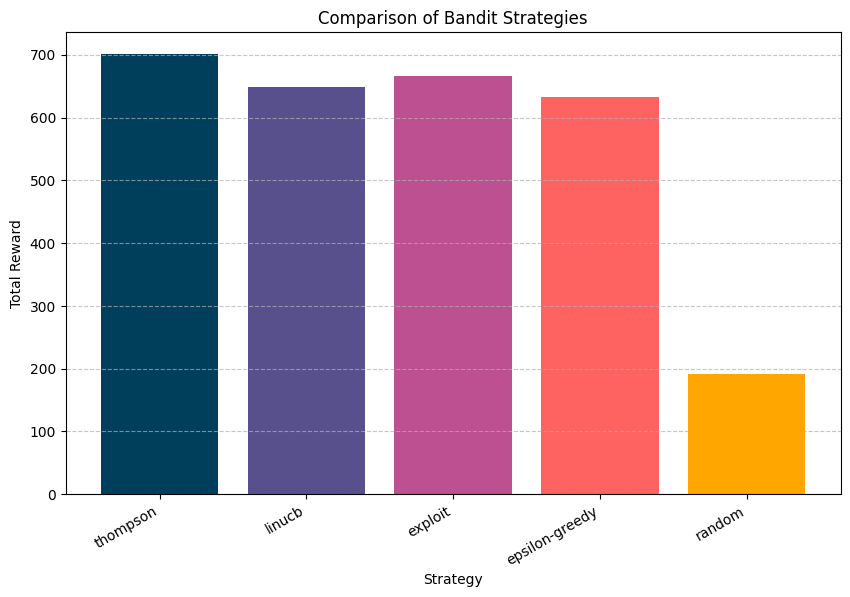

In [3]:
strategies = [
    "thompson",
    "linucb",
    "exploit",
    "epsilon-greedy",
    "random"
]

results = []
cumulative_regrets = {}

for strategy in strategies:
    strategy_name, reward, regret = evaluate_bandit(strategy)
    results.append((strategy_name, reward))
    cumulative_regrets[strategy_name] = regret

# Extract strategy names and rewards for plotting
strategy_names, rewards = zip(*results)

# Plot rewards and regret
plot_results(strategy_names, rewards, cumulative_regrets)

## Effect of Alpha on Thompson Sampling Regret

In this experiment, we analyze how different values of the exploration parameter **alpha** impact the cumulative regret of Thompson Sampling. The parameter **alpha** controls the exploration-exploitation trade-off, where higher values encourage more exploration.

### Experiment Setup:
1. Run Thompson Sampling with varying alpha values: `[0.1, 0.25, 0.5, 1.0, 2.0]`.
2. Track cumulative regret over time for each alpha value.
3. Visualize the results to observe the impact on learning efficiency.

The expectation is that higher values of alpha may lead to better exploration initially, while lower values could result in faster convergence to suboptimal solutions.


Strategy: thompson, Total reward: 684/1000
Strategy: thompson, Total reward: 701/1000
Strategy: thompson, Total reward: 667/1000
Strategy: thompson, Total reward: 611/1000
Strategy: thompson, Total reward: 484/1000


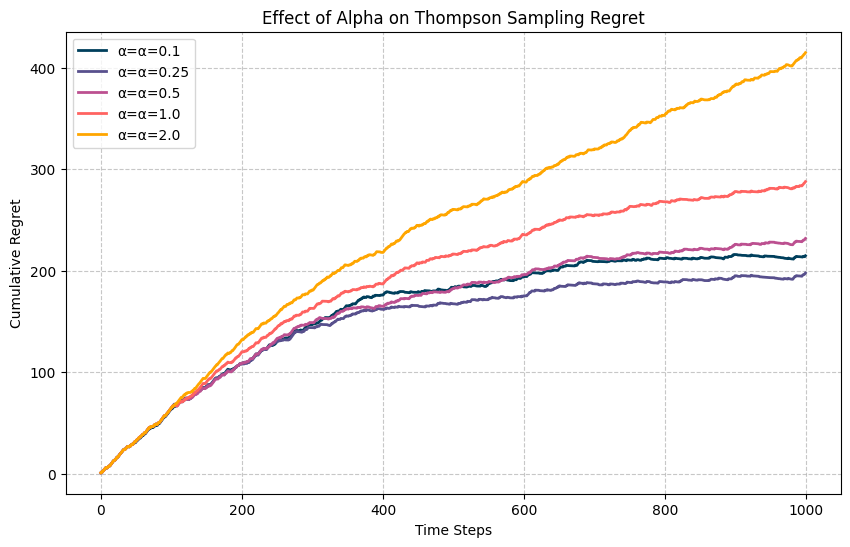

In [4]:
alpha_values = [0.1, 0.25, 0.5, 1.0, 2.0]

# Store results
cumulative_regrets = {}
# Evaluate Thompson Sampling for each alpha value
for alpha in alpha_values:
    strategy_name, reward, regret = evaluate_bandit(strategy="thompson", alpha_thompson=alpha)
    cumulative_regrets[f"α={alpha}"] = regret

plot_alpha_regret(cumulative_regrets)

## Impact of Batch Size on Learning Performance

In this experiment, we analyze how different batch sizes affect the learning performance of Thompson Sampling. The batch size determines how often model updates occur, impacting both computational efficiency and regret minimization.

The goal is to assess the trade-off between frequent updates (faster learning) and computational efficiency.

Strategy: thompson, Total reward: 797/1000
Strategy: thompson, Total reward: 769/1000
Strategy: thompson, Total reward: 735/1000
Strategy: thompson, Total reward: 701/1000


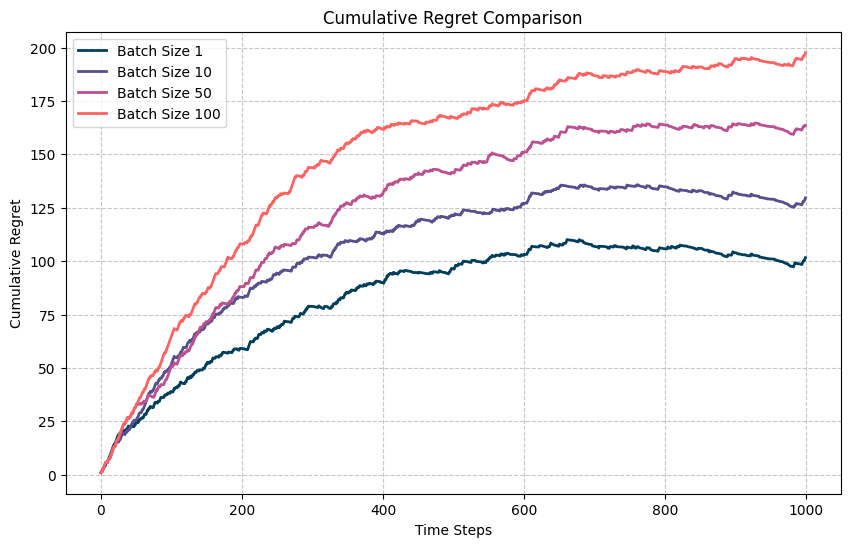

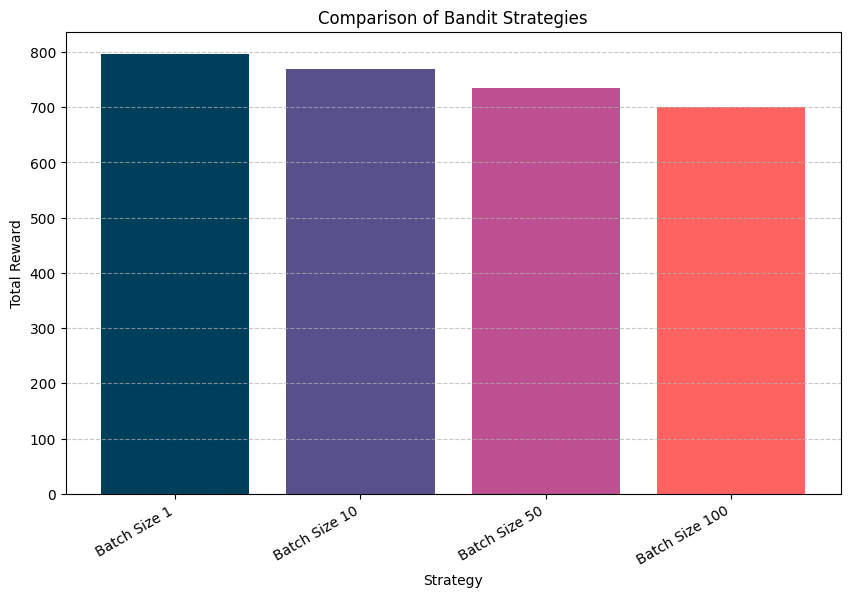

In [6]:
# Define different batch sizes for the experiment
batch_sizes = [1, 10, 50, 100]

# Store results for plotting
results = []
cumulative_regrets = {}

# Evaluate Thompson Sampling with varying batch sizes
for batch_size in batch_sizes:
    strategy_name, reward, regret = evaluate_bandit(strategy="thompson", batch_size=batch_size)
    results.append((f"Batch Size {batch_size}", reward))
    cumulative_regrets[f"Batch Size {batch_size}"] = regret

# Extract strategy names and rewards for plotting
strategy_names, rewards = zip(*results)

# Plot results using utility function
plot_results(strategy_names, rewards, cumulative_regrets)